In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
DATA_DIR = "../../data/raw/"

EXCLUIR = [
    "freshbittergroud", "rottenbittergroud",
    "freshcapsicum", "rottencapsicum"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

In [3]:
def cargar_imagenes(split):
    imagenes = []
    etiquetas = []
    
    ruta_split = os.path.join(DATA_DIR, split)
    
    for clase in os.listdir(ruta_split):
        if clase in EXCLUIR:
            continue
        
        if clase.startswith("fresh"):
            etiqueta = 0  # fresh = 0
        elif clase.startswith("rotten"):
            etiqueta = 1  # rotten = 1
        else:
            continue
        
        ruta_clase = os.path.join(ruta_split, clase)
        for img_nombre in os.listdir(ruta_clase):
            imagenes.append(os.path.join(ruta_clase, img_nombre))
            etiquetas.append(etiqueta)
    
    return imagenes, etiquetas

print("Cargando rutas de imágenes...")
train_paths, train_labels = cargar_imagenes("Train")
test_paths, test_labels = cargar_imagenes("Test")

print(f"Train: {len(train_paths)} imágenes")
print(f"Test:  {len(test_paths)} imágenes")

Cargando rutas de imágenes...
Train: 21044 imágenes
Test:  6738 imágenes


In [4]:
def procesar_imagen(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

# Data augmentation solo para Train
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
])

def procesar_train(path, label):
    img, label = procesar_imagen(path, label)
    img = augmentation(img, training=True)
    return img, label

# Crear datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.shuffle(len(train_paths), seed=SEED)
train_ds = train_ds.map(procesar_train, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(procesar_imagen, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets listos")

Datasets listos


In [5]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Congelamos los pesos pre-entrenados

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')  # 1 neurona: fresh o rotten
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224          │ (None, 7, 7, 1280)    │    2,257,984 │
│ (Functional)                  │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ global_average_pooling2d      │ (None, 1280)          │            0 │
│ (GlobalAveragePooling2D)      │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense (Dense)                 │ (None, 128)           │      163,968 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dropout (Dropout)             │ (None, 128)           │            0 │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_1 (Dense)               │ (None, 1)             │          129 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS
)

Epoch 1/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 239s 358ms/step - accuracy: 0.5661 - loss: 0.6800 - val_accuracy: 0.8448 - val_loss: 0.3435
Epoch 2/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 222s 337ms/step - accuracy: 0.5947 - loss: 0.6500 - val_accuracy: 0.8673 - val_loss: 0.3097
Epoch 3/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 218s 332ms/step - accuracy: 0.6005 - loss: 0.6439 - val_accuracy: 0.8943 - val_loss: 0.2567
Epoch 4/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 220s 335ms/step - accuracy: 0.6128 - loss: 0.6313 - val_accuracy: 0.8408 - val_loss: 0.3797
Epoch 5/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 226s 344ms/step - accuracy: 0.6207 - loss: 0.6230 - val_accuracy: 0.9242 - val_loss: 0.2023
Epoch 6/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 227s 345ms/step - accuracy: 0.6158 - loss: 0.6198 - val_accuracy: 0.8670 - val_loss: 0.3127
Epoch 7/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 215s 327ms/step - accuracy: 0.6232 - loss: 0.6197 - val_accuracy: 0.9184 - val_loss: 0.2046
Epoch 8/20
658/658 ━━━━━━━━━━━━━━━━━━━━ 219s 333ms/step - accuracy: 0.6233 -

In [9]:
model.save("../../model/saved_model/modelo_fruta.keras")
print("Modelo guardado en model/saved_model/")

Modelo guardado en model/saved_model/


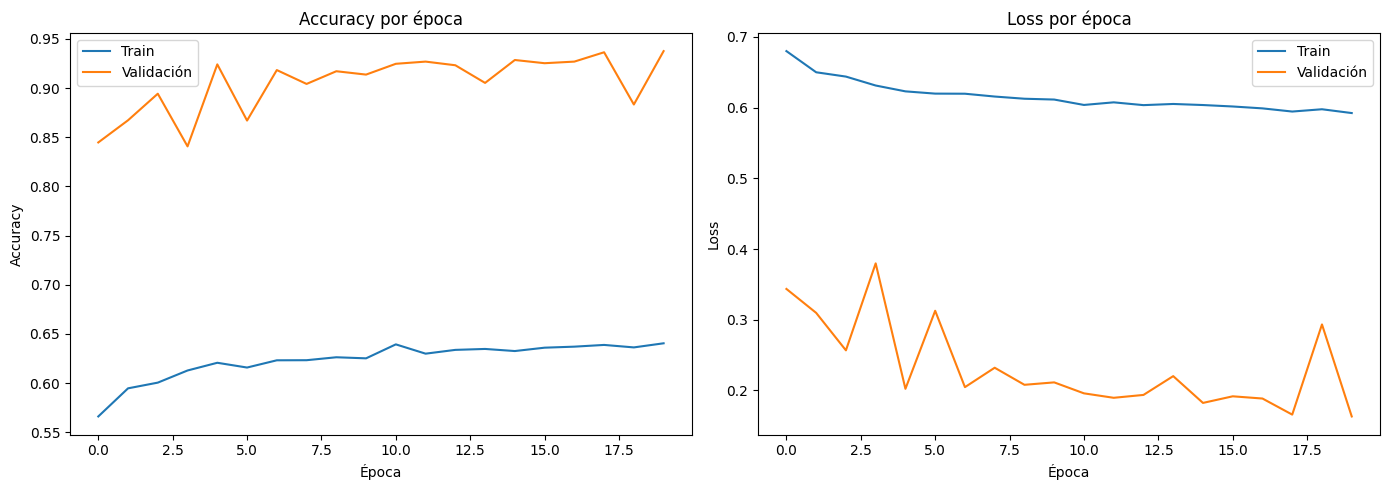

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validación')
axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validación')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()